<a href="https://colab.research.google.com/github/diazveraserrano-boop/Procesamiento-de-Imagen/blob/main/Imagen2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad imagen 2
La segunda imagen consiste en un cultivo celular con colores predominantemente marrones. El objetivo es intentar aproximarnos al número real de células que hay en la imagen sin utilizar métodos de aprendizaje supervisado. Para ello se ha seguido la siguiente estructura:

*   Descarga de la imagen e importación de librerías
*   Preprocesamiento de la imagen
*   Aplicación de un método de umbralización
*   Posprocesamiento y conteo celular





## Descarga de la imagen e importación de librerías

In [1]:
!pip install onedrivedownloader
from onedrivedownloader import download
from skimage import io, color, filters, exposure
from skimage.filters import gaussian, threshold_otsu
from skimage import morphology
from skimage import measure
from skimage.color import label2rgb
import matplotlib.pyplot as plt
import numpy as np

# Justificación: skimage para procesamiento (visto en clase), matplotlib para visualización, numpy para arrays.

In [2]:
path_file_2 = 'https://universidadfv-my.sharepoint.com/:i:/g/personal/alberto_desantos_ufv_es/EVq7WDpsmUdNpimem9qtc-0Btj8E9McUzg9IccKZN2f-rg?e=tNV0Dz'
download(url = path_file_2, filename = 'Imagen 2.jpg', unzip=False, force_download=True, clean=False)

100%|██████████| 336k/336k [00:00<00:00, 634kiB/s]


'Imagen 2.jpg'

Mostramos la imagen por pantalla para comprobar que se ha descargado bien y que se puede proceder a su tratamiento

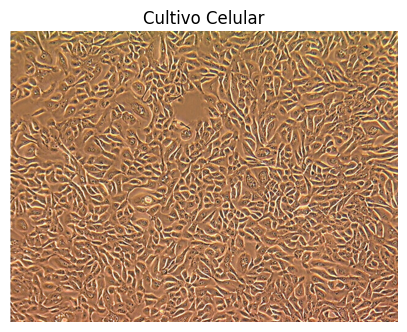

In [3]:
img2 = io.imread("/content/Imagen 2.jpg")

plt.figure(figsize=(5, 5))
plt.imshow(img2)
plt.title('Cultivo Celular')
plt.axis('off')
plt.show()

## Preprocesamiento de la imagen


Tras pruebas en distintos canales del espacio LAB, HSV, RGB y en escala de grises se determinó que una de las mejores distinciones entre bode celular y célula se observaba en el canal V del espacio HSV.

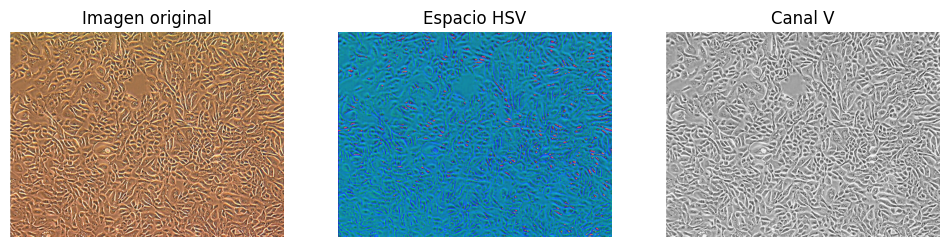

In [4]:
img_lab = color.rgb2hsv(img2)                # Convertir de RGB a espacio HSV
v = img_lab[:, :, 2]                        # Extraer canal V

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img2); plt.title('Imagen original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(img_lab); plt.title('Espacio HSV'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(v, cmap='gray'); plt.title('Canal V'); plt.axis('off')
plt.show()

Ahora hacemos un preprocesamiento antes de aplicar el método de umbralización. Primero utilizamos un filtro gaussiano para eliminar ruido de alta frecuencia y después aumentamos el contraste para realzar más la diferencia entre interior celular y borde celular.

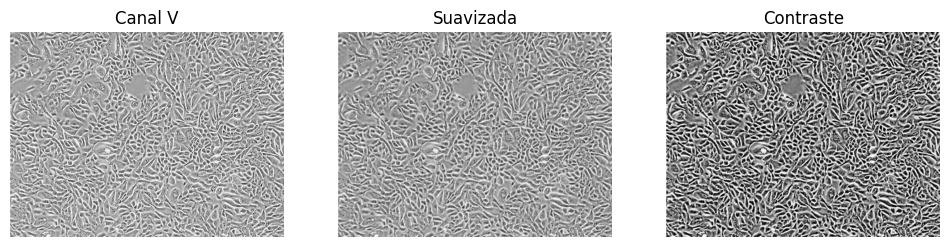

In [7]:
img2_smooth = filters.gaussian(v, sigma=1)  # Suavizar para reducir ruido sin borrar forma celular. Sigma = 1 realiza un suavizado moderado, eliminando ruido de alta frecuencia y manteniendo la forma celular
img2_eq = exposure.equalize_adapthist(img2_smooth)  # Mejorar contraste local para separar célula/fondo

plt.figure(figsize=(12,4))                   # Crear lienzo ancho para comparar etapas
plt.subplot(1,3,1); plt.imshow(v, cmap='gray'); plt.title('Canal V'); plt.axis('off')        # Canal V
plt.subplot(1,3,2); plt.imshow(img2_smooth, cmap='gray'); plt.title('Suavizada'); plt.axis('off') # Suavizada
plt.subplot(1,3,3); plt.imshow(img2_eq, cmap='gray'); plt.title('Contraste'); plt.axis('off')     # Contraste mejorado
plt.show()


## Aplicamos método de umbralización

Aplicamos umbralización adaptativa, que se emplea en lugar del método de Otsu, cuando la iluminación y el contraste no son homogéneos en toda la imagen. Mientras que Otsu calcula un único umbral en toda la imagen, que será ineficiente en zonas donde varíe la iluminación hacia más oscuro o más brillante, el método adaptativo calcula un umbral distinto para cada vecindario, ajustándose localmente a la variación de intensidad.

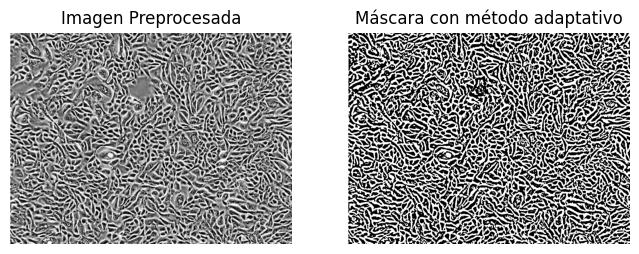

In [8]:
img_eq_norm = (img2_eq - img2_eq.min()) / (img2_eq.max() - img2_eq.min())  # Normalizar a [0,1]
th_local = filters.threshold_local(img_eq_norm, block_size=35, offset=-0.01)  # Umbral por vecindario
binary_adapt = img_eq_norm > th_local # Máscara binaria final

# Visualización rápida de control
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img2_eq, cmap='gray'); plt.title('Imagen Preprocesada'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(binary_adapt, cmap='gray'); plt.title('Máscara con método adaptativo'); plt.axis('off')
plt.show()

En el mapa de umbrales adaptativos vemos como el valor de corte cambia según la iluminación. Las áreas más claras presentan umbrales más altos y las más oscuras, más bajos. Esto permite separar de forma más precisa las estructuras celulares del fondo, logrando una segmentación más homogénea en toda la muestra.

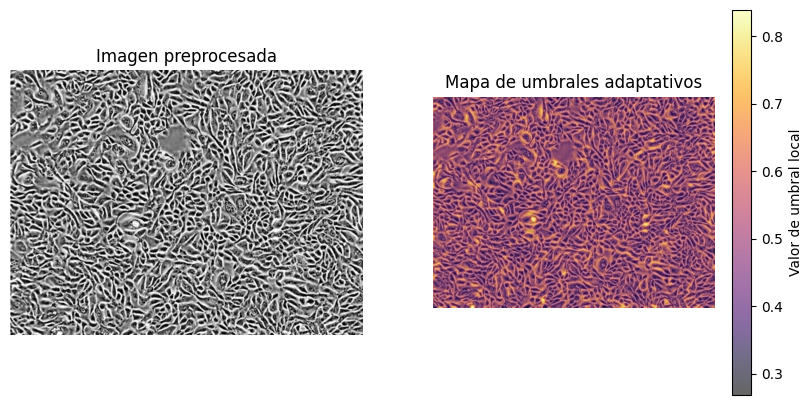

In [9]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img2_eq, cmap='gray')
plt.title('Imagen preprocesada')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2_eq, cmap='gray')
plt.imshow(th_local, cmap='inferno', alpha=0.6)
plt.title('Mapa de umbrales adaptativos')
plt.axis('off')
plt.colorbar(label='Valor de umbral local')
plt.show()

## Posprocesamiento y conteo celular

Antes de empezar a contar hacemos un posprocesamiento de la máscara binaria. Primero aplicamos el método de clausura (dilatasión + erosión) de manera que se unan los distintos bordes celulares y no hayan células fusionadas entre sí que provocarían que el método de conteo celular (labels) se equivocara. Se ha observado que un tamaño del disco de 2 es el óptimo puesto que con un tamaño de 1 todavía no se han cerrado todos los bordes, haciendo que hayan grupos de píxeles (que equivalen a interiores células) unidos entre sí y no den un número correcto; y con un tamaño de 3 los espacios se cierran deasiado, elevando mucho el número de células, ya que puede estar dividiendo una célula en varias partes completamente aisladas. También rellenamos pequeños huecos que no equivalen a células con el método remove_small_holes para reducir el número de células a algo más realista

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

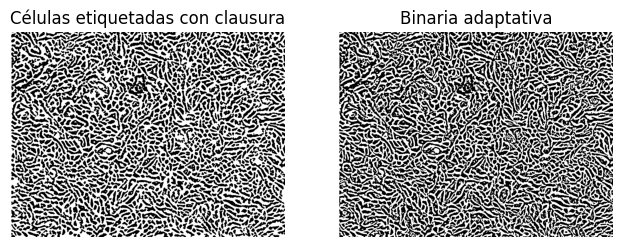

In [10]:
mask = morphology.binary_closing(binary_adapt, morphology.disk(2))      # Suavizar bordes y eliminar ruido fino
mask = morphology.remove_small_holes(mask, area_threshold=50)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mask, cmap='gray'); plt.title('Células etiquetadas con clausura'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(binary_adapt, cmap='gray'); plt.title('Binaria adaptativa'); plt.axis('off')

Contamos las células con el método label, que asigna un valor a cada grupo de píxeles unido. Al principio hubo confusión con este método porque si lo aplicábamos sobre las máscara directamente, el método contaba el interior celular como 0 y contaba los bordes celulares, dando lugar a un resultado erróneo. Aplicando label a (1 - mask) invertimos el resultado, etiquetando así los interiores celulares. También, nos hemos dado cuenta que el fondo de la imagen es de la misma escala de colores que los interiores celulares, esto hace que el método label identifique el fondo de la imagen como una célula más. Para corregirlo, hacemos que agrupaciones más grandes de 3000 píxeles no sean contadas como label, asignándolas valor 0

Número de células detectadas: 1389


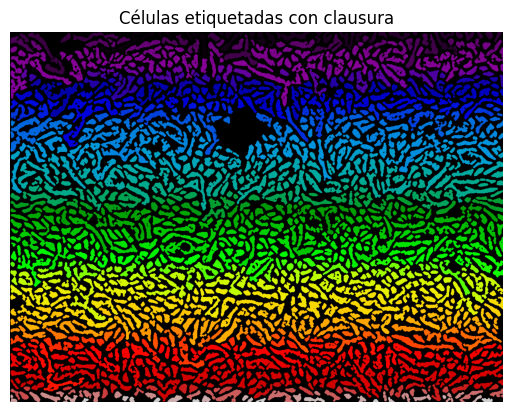

In [11]:
labels = measure.label(1-mask)  # Etiquetar regiones conectadas
props = measure.regionprops(labels)  # Obtener propiedades geométricas

area_max = 3000  # Rango de área aceptable en píxeles

# Eliminar agrupaciones demasiado grandes
for region in props:
    if region.area > area_max:
        labels[labels == region.label] = 0  # Poner a 0 las regiones grandes (fondo o masas)

labels_final = measure.label(labels > 0) # Re-etiquetar sólo regiones válidas

print("Número de células detectadas:", len(measure.regionprops(labels_final)))

plt.imshow(labels_final, cmap='nipy_spectral'); plt.axis('off'); plt.title('Células etiquetadas con clausura'); plt.show()

Como vemos se ha obtenido un valor realista de células, la máscara parece que encaja con los interiores celulares, pero para comprobarlo la sobreponemos encima de la imagen original.

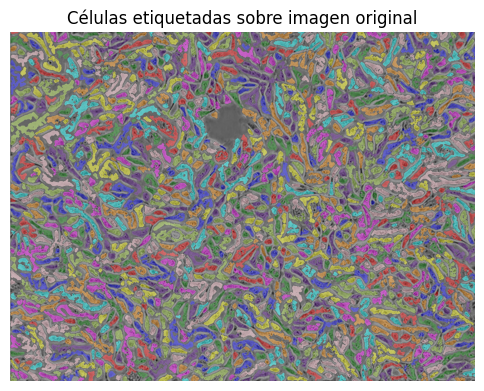

In [12]:
overlay = label2rgb(labels_final, image=img2, bg_label=0, alpha=0.4, kind='overlay')
# Combina la imagen original y las etiquetas con transparencia

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title('Células etiquetadas sobre imagen original')
plt.axis('off')
plt.show()


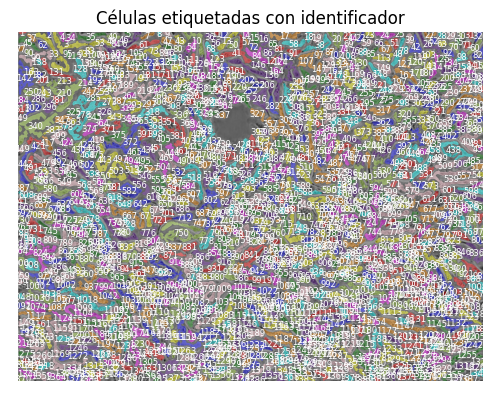

In [13]:
# Ponemos un número en cada label
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(overlay)
for region in measure.regionprops(labels_final):
    y, x = region.centroid
    ax.text(x, y, str(region.label), color='white', fontsize=6, ha='center', va='center')
ax.set_title('Células etiquetadas con identificador')
ax.axis('off')
plt.show()


## Conclusión

Se puede ver que los espacios celulares de la máscara se corresponden muy bien con los de la imagen celular, concluyendo que se ha obtenido un buen método de conteo mediante métodos no supervisados. También, cabe destacar que con métodos supervisados hubiera sido una tarea más sencilla, lo que pone en valor su existencia y uso.